<a href="https://colab.research.google.com/github/katbee1/Data-analytics/blob/main/FRED%20DJIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploring FRED Data

We download the latest FRED DIJA data from https://fred.stlouisfed.org/series/DJIA in CSV format and load it into Pandas

In [15]:
URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=DJIA&scale=left&cosd=2021-03-23&coed=2026-03-23&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Daily%2C%20Close&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2026-03-24&revision_date=2026-03-24&nd=2016-03-24"

In [21]:
import pandas as pd

df = pd.read_csv(URL)

Analysis of code quality

In [22]:
number_of_nulls = df.isnull().sum().sum()
print("There are " + str(number_of_nulls)+ " null values")


There are 49 null values


In [24]:
print("These are the columns with null values:")
df.isnull().sum()

These are the columns with null values:


,0
observation_date,0
DJIA,49


In [23]:
num_rows = len(df)
null_ratio = number_of_nulls / num_rows
#we can use Fstrings in Python to format our strings

print(f"The null ratio is {null_ratio * 100:.2f} % of the data is null")

The null ratio is 3.75 % of the data is null


We can create a graph to visualize the data

[Text(0.5, 1.0, 'DJIA over time')]

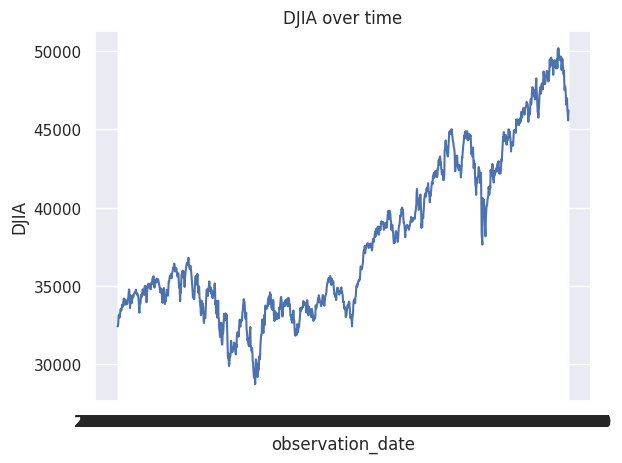

In [26]:
import seaborn as sns

sns.set_theme()

ax = sns.lineplot(df, x="observation_date", y="DJIA")
ax.set(title="DJIA over time")


[Text(0.5, 1.0, 'DJIA over time')]

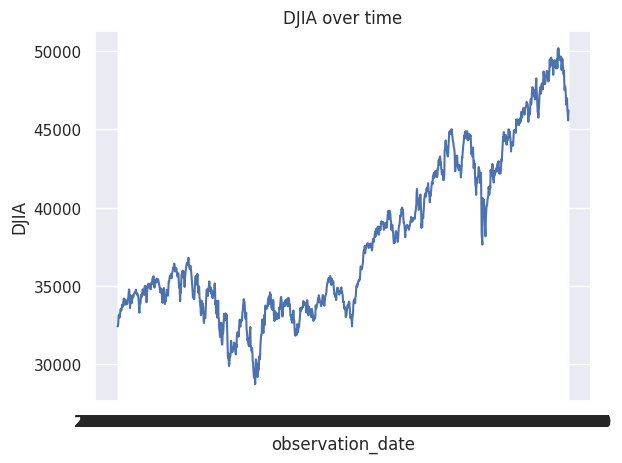

In [28]:
df2 = df.fillna(0)
ax = sns.lineplot(df, x="observation_date", y="DJIA")
ax.set(title="DJIA over time")

Cleaning Data

In [30]:
print(len(df))
print(len(df.dropna(axis=0, how='any')))
# We drop the rows that contain ANY NaN/null values
df = df.dropna(axis=0, how='any')
df

1305
1256


,observation_date,DJIA
0,2021-03-23,32423.15
1,2021-03-24,32420.06
2,2021-03-25,32619.48
3,2021-03-26,33072.88
4,2021-03-29,33171.37
...,...,...
1300,2026-03-17,46993.26
1301,2026-03-18,46225.15
1302,2026-03-19,46021.43
1303,2026-03-20,45577.47


We can manipulate columns

In [33]:
# We can create a new column
df["S&P"] = df["DJIA"] / 10

/tmp/ipykernel_15325/1594598000.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["S&P"] = df["DJIA"] / 10


In [34]:
# We can drop the new column using df.drop
df.drop(["S&P"], axis=1, inplace=True)
# Is strictly equivalent to
# df = df.drop(["S&P"], axis=1)

/tmp/ipykernel_15325/470381945.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(["S&P"], axis=1, inplace=True)


In [35]:
df

,observation_date,DJIA
0,2021-03-23,32423.15
1,2021-03-24,32420.06
2,2021-03-25,32619.48
3,2021-03-26,33072.88
4,2021-03-29,33171.37
...,...,...
1300,2026-03-17,46993.26
1301,2026-03-18,46225.15
1302,2026-03-19,46021.43
1303,2026-03-20,45577.47
